In [26]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [27]:
'''
# --- 1. LETTURA DEL FILE result.txt ---
filename = "single_result.txt"
temps = []
k_effs = []
stds = []

# Parser robusto: salta l'header e legge solo le righe che iniziano con numeri
with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        # Se il primo carattere è un numero, assumiamo sia una riga dati
        if line[0].isdigit():
            parts = line.split()
            if len(parts) >= 3:
                temps.append(float(parts[0]))
                k_effs.append(float(parts[1]))
                stds.append(float(parts[2]))

T_data = np.array(temps)
k_data = np.array(k_effs)
err_data = np.array(stds)

# pcm = (k_data - 1)/(10e-5*k_data)     NON è STRADA CORRETTA

# --- 3. PLOTTING (Stile Unificato) ---
fig, ax = plt.subplots(figsize=(16, 10))

# Plot dei dati con barre d'errore
ax.errorbar(T_data, k_data, yerr=err_data, 
            fmt='o',                  # Punti senza linea di congiunzione
            color='#000000',          # Colore punti
            ecolor='#789DD1',         # Colore barre errore
            elinewidth=2,             # Spessore barre
            capsize=5,                # Cappuccetto barre
            label='Dati Monte Carlo',
            zorder=5)

# Formattazione Stile
font_labels = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}

ax.set_xlabel('Temperatura [K]', **font_labels)
ax.set_ylabel('k_eff', **font_labels)
ax.set_title('Andamento di k_eff in funzione della Temperatura', fontsize=16, fontweight='bold')

# Griglia
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()
'''

'\n# --- 1. LETTURA DEL FILE result.txt ---\nfilename = "single_result.txt"\ntemps = []\nk_effs = []\nstds = []\n\n# Parser robusto: salta l\'header e legge solo le righe che iniziano con numeri\nwith open(filename, \'r\') as f:\n    for line in f:\n        line = line.strip()\n        if not line: continue\n        # Se il primo carattere è un numero, assumiamo sia una riga dati\n        if line[0].isdigit():\n            parts = line.split()\n            if len(parts) >= 3:\n                temps.append(float(parts[0]))\n                k_effs.append(float(parts[1]))\n                stds.append(float(parts[2]))\n\nT_data = np.array(temps)\nk_data = np.array(k_effs)\nerr_data = np.array(stds)\n\n# pcm = (k_data - 1)/(10e-5*k_data)     NON è STRADA CORRETTA\n\n# --- 3. PLOTTING (Stile Unificato) ---\nfig, ax = plt.subplots(figsize=(16, 10))\n\n# Plot dei dati con barre d\'errore\nax.errorbar(T_data, k_data, yerr=err_data, \n            fmt=\'o\',                  # Punti senza linea d

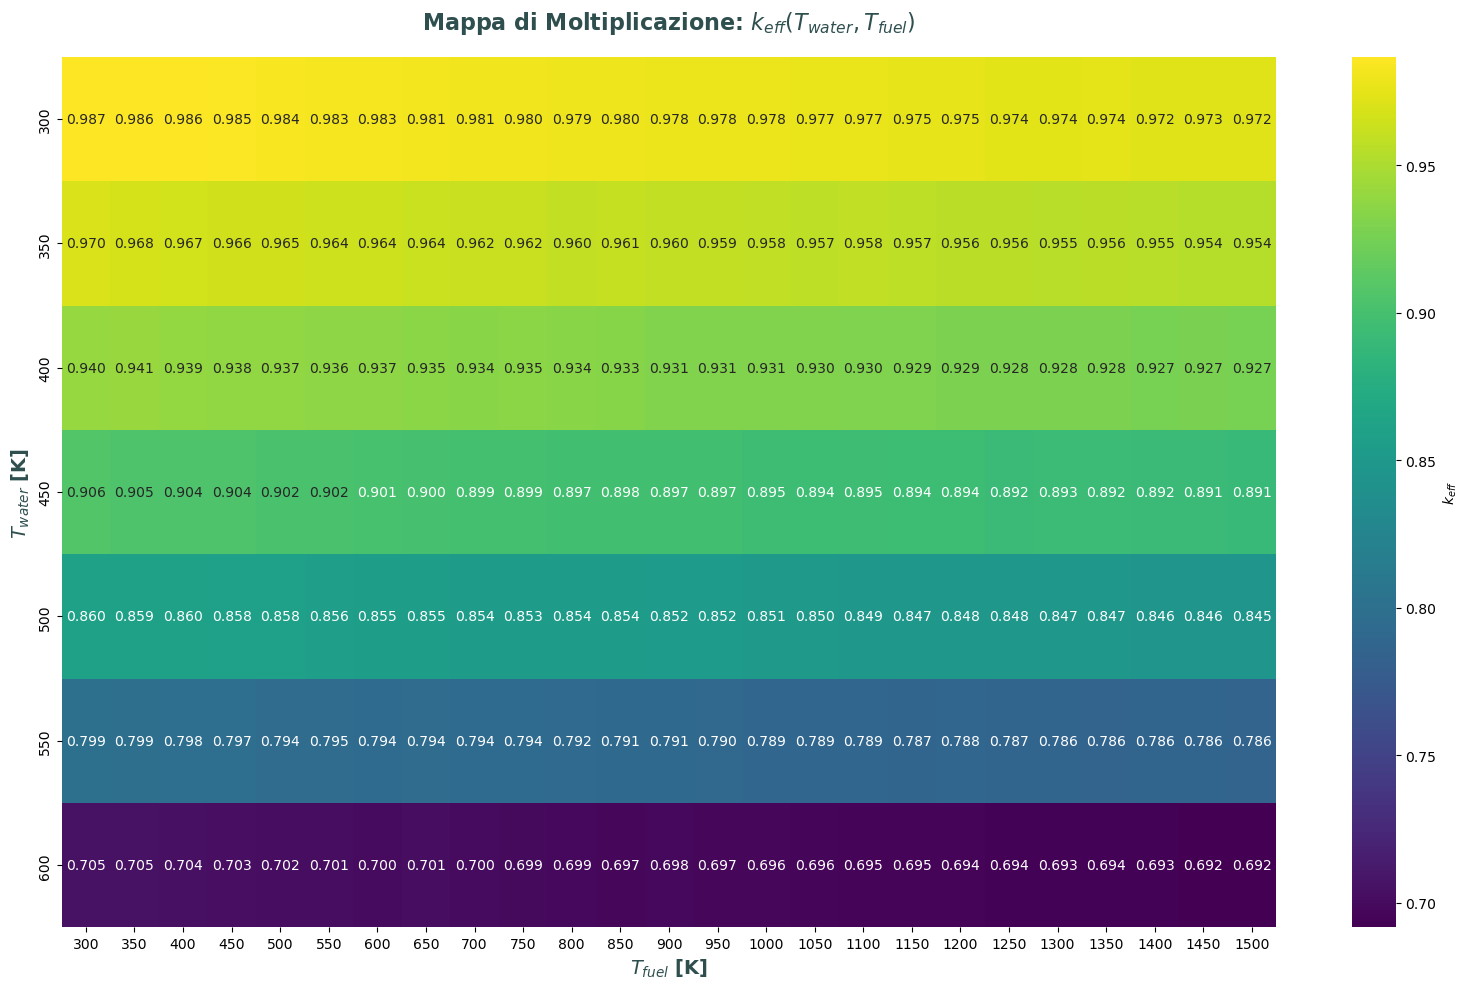

In [28]:
# 1. Parsing robusto del file di output
data = []
with open("result.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        # Isolamento delle righe contenenti le 4 grandezze fisiche
        if len(parts) == 4:
            try:
                t_w = float(parts[0])
                t_f = float(parts[1])
                k = float(parts[2])
                err = float(parts[3])
                data.append([int(t_w), int(t_f), k, err])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=['T_water', 'T_fuel', 'k_eff', 'std_dev'])

# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_eff')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione: $k_{eff}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

plt.tight_layout()
plt.show()

T_water = 300 K | m = -1.2282e-05 +/- 2.8847e-07 | q = 9.8997e-01 +/- 2.8132e-04
T_water = 350 K | m = -1.2298e-05 +/- 4.3679e-07 | q = 9.7134e-01 +/- 4.2544e-04
T_water = 400 K | m = -1.1672e-05 +/- 3.7629e-07 | q = 9.4318e-01 +/- 3.6049e-04
T_water = 450 K | m = -1.2452e-05 +/- 4.6017e-07 | q = 9.0854e-01 +/- 4.4558e-04
T_water = 500 K | m = -1.2587e-05 +/- 3.5411e-07 | q = 8.6359e-01 +/- 3.4388e-04
T_water = 550 K | m = -1.1459e-05 +/- 4.3516e-07 | q = 8.0162e-01 +/- 4.2087e-04
T_water = 600 K | m = -1.0992e-05 +/- 3.5088e-07 | q = 7.0761e-01 +/- 3.4348e-04


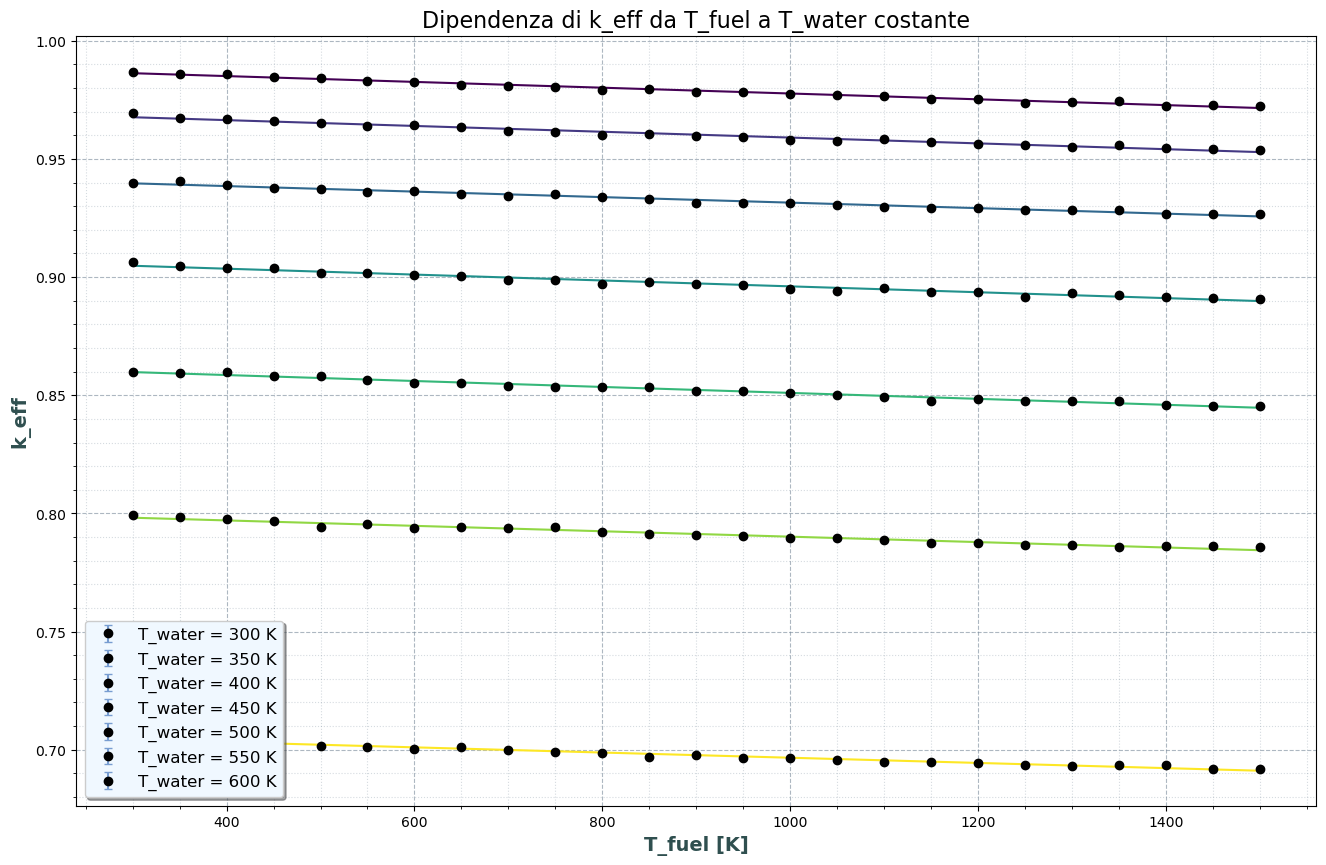

In [29]:
plt.figure(figsize=(16, 10))
t_waters = df['T_water'].unique()
colori_tw = plt.cm.viridis(np.linspace(0, 1, len(t_waters)))

m_values = []
err_m_values = []

for i, tw in enumerate(t_waters):
    df_sub = df[df['T_water'] == tw]
    x = df_sub['T_fuel']
    y = df_sub['k_eff']
    yerr = df_sub['std_dev']

    # Fit lineare pesato: y = m*x + q
    # Usiamo w = 1/yerr (np.polyfit richiede i pesi come 1/sigma)
    p, cov = np.polyfit(x, y, 1, w=1/yerr, cov=True)
    m, q = p
    err_m, err_q = np.sqrt(np.diag(cov))

    # Salvataggio dei coefficienti
    m_values.append(m)
    err_m_values.append(err_m)

    # Stampa dei parametri a schermo
    print(f"T_water = {tw:.0f} K | m = {m:.4e} +/- {err_m:.4e} | q = {q:.4e} +/- {err_q:.4e}")

    # Plot dei punti con barre d'errore
    plt.errorbar(x, y, yerr=yerr,
                 fmt='o', color=colori_tw[i],
                 markerfacecolor='#000000', markeredgecolor='#000000',
                 ecolor='#789DD1', capsize=3,
                 label=f'T_water = {int(tw)} K')

    # Plot della retta di fit
    plt.plot(x, np.polyval(p, x), '-', color=colori_tw[i])
    m_array = np.array(m_values)
    err_m_array = np.array(err_m_values)

plt.title('Dipendenza di k_eff da T_fuel a T_water costante', fontsize=16)
plt.xlabel('T_fuel [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

In [30]:
# 1. Calcolo dei pesi (inversamente proporzionali alla varianza)
pesi = 1.0 / (err_m_array**2)

# 2. Calcolo della media pesata e del suo errore
m_mean = np.sum(m_array * pesi) / np.sum(pesi)
err_m_mean = 1.0 / np.sqrt(np.sum(pesi))

print(f"--- RISULTATI MEDIA PESATA ---")
print(f"Media pesata (m): {m_mean:.4e} +/- {err_m_mean:.4e}\n")

# 3. Valutazione della compatibilità
print(f"--- COMPATIBILITÀ DEI SINGOLI VALORI ---")
for i, (m, err_m) in enumerate(zip(m_array, err_m_array)):
    # Propagazione dell'errore per la differenza (m - m_mean)
    sigma_diff = np.sqrt(err_m**2 + err_m_mean**2)
    
    # Distanza in deviazioni standard (Z-score)
    z_score = np.abs(m - m_mean) / sigma_diff
    
    # Criterio standard di 3 sigma per la compatibilità
    is_compatibile = "SI" if z_score <= 2.0 else "NO"
    
    print(f"Dataset {i+1}: m = {m:.4e} +/- {err_m:.4e} | "
          f"Scarto: {np.abs(m - m_mean):.4e} | "
          f"Distanza: {z_score:.2f} σ | Compatibile (< 2σ): {is_compatibile}")

--- RISULTATI MEDIA PESATA ---
Media pesata (m): -1.1968e-05 +/- 1.4083e-07

--- COMPATIBILITÀ DEI SINGOLI VALORI ---
Dataset 1: m = -1.2282e-05 +/- 2.8847e-07 | Scarto: 3.1390e-07 | Distanza: 0.98 σ | Compatibile (< 2σ): SI
Dataset 2: m = -1.2298e-05 +/- 4.3679e-07 | Scarto: 3.2925e-07 | Distanza: 0.72 σ | Compatibile (< 2σ): SI
Dataset 3: m = -1.1672e-05 +/- 3.7629e-07 | Scarto: 2.9663e-07 | Distanza: 0.74 σ | Compatibile (< 2σ): SI
Dataset 4: m = -1.2452e-05 +/- 4.6017e-07 | Scarto: 4.8380e-07 | Distanza: 1.01 σ | Compatibile (< 2σ): SI
Dataset 5: m = -1.2587e-05 +/- 3.5411e-07 | Scarto: 6.1845e-07 | Distanza: 1.62 σ | Compatibile (< 2σ): SI
Dataset 6: m = -1.1459e-05 +/- 4.3516e-07 | Scarto: 5.0888e-07 | Distanza: 1.11 σ | Compatibile (< 2σ): SI
Dataset 7: m = -1.0992e-05 +/- 3.5088e-07 | Scarto: 9.7658e-07 | Distanza: 2.58 σ | Compatibile (< 2σ): NO


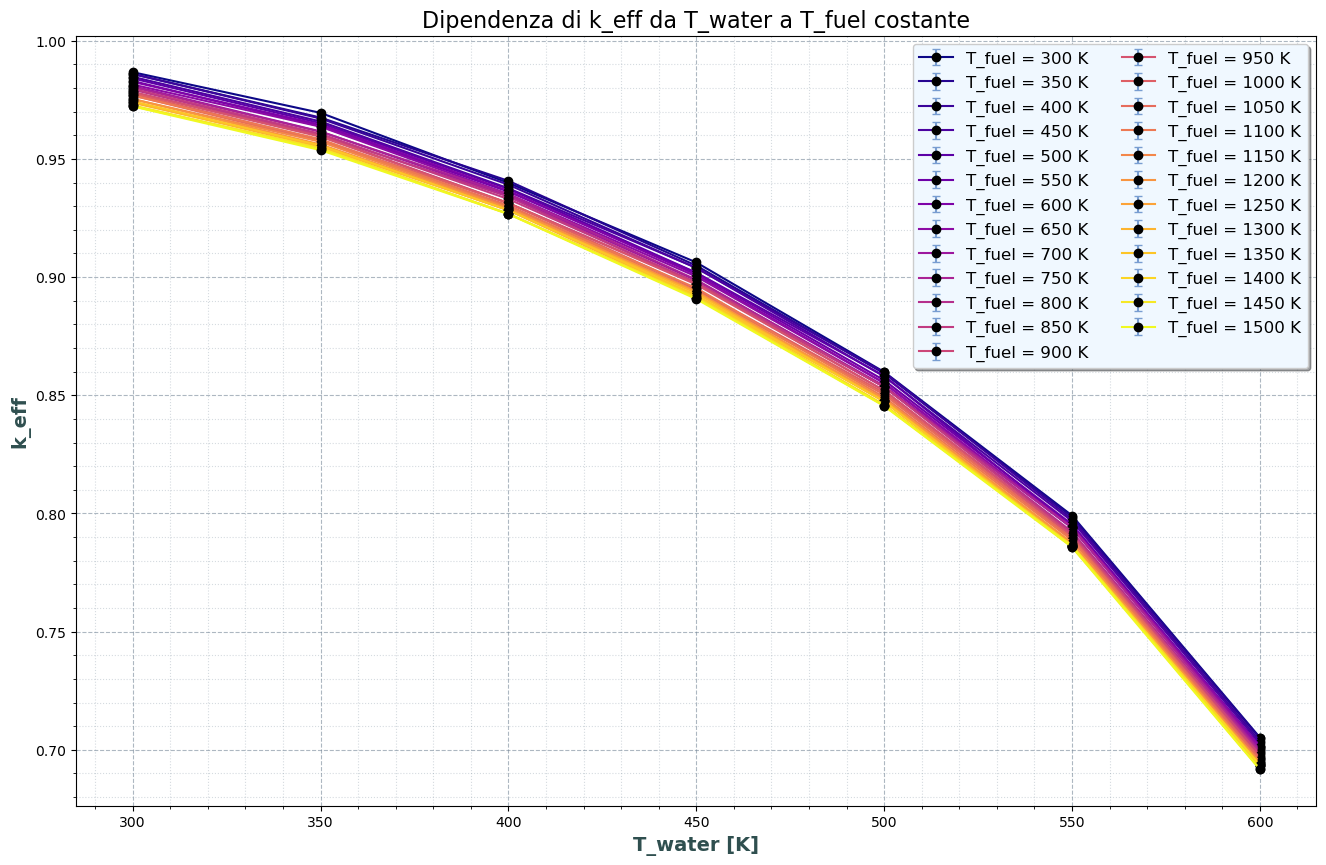

In [31]:
plt.figure(figsize=(16, 10))
t_fuels = df['T_fuel'].unique()
colori_tf = plt.cm.plasma(np.linspace(0, 1, len(t_fuels)))

for i, tf in enumerate(t_fuels):
    df_sub = df[df['T_fuel'] == tf]
    plt.errorbar(df_sub['T_water'], df_sub['k_eff'], yerr=df_sub['std_dev'],
                 fmt='o-', color=colori_tf[i],
                 markerfacecolor='#000000', markeredgecolor='#000000',
                 ecolor='#789DD1', capsize=3,
                 label=f'T_fuel = {int(tf)} K')

plt.title('Dipendenza di k_eff da T_water a T_fuel costante', fontsize=16)
plt.xlabel('T_water [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF', ncol=2)

plt.show()

T_water = 300 K | m = -1.2824e-05 +/- 2.9430e-07 | q = -1.0015e-02 +/- 2.8525e-04
T_water = 350 K | m = -1.3352e-05 +/- 4.6456e-07 | q = -2.9374e-02 +/- 4.4968e-04
T_water = 400 K | m = -1.3427e-05 +/- 4.2520e-07 | q = -6.0116e-02 +/- 4.0479e-04
T_water = 450 K | m = -1.5479e-05 +/- 5.6085e-07 | q = -1.0051e-01 +/- 5.3948e-04
T_water = 500 K | m = -1.7337e-05 +/- 4.8039e-07 | q = -1.5778e-01 +/- 4.6315e-04
T_water = 550 K | m = -1.8318e-05 +/- 6.8369e-07 | q = -2.4727e-01 +/- 6.5656e-04
T_water = 600 K | m = -2.2606e-05 +/- 7.0397e-07 | q = -4.1293e-01 +/- 6.8403e-04


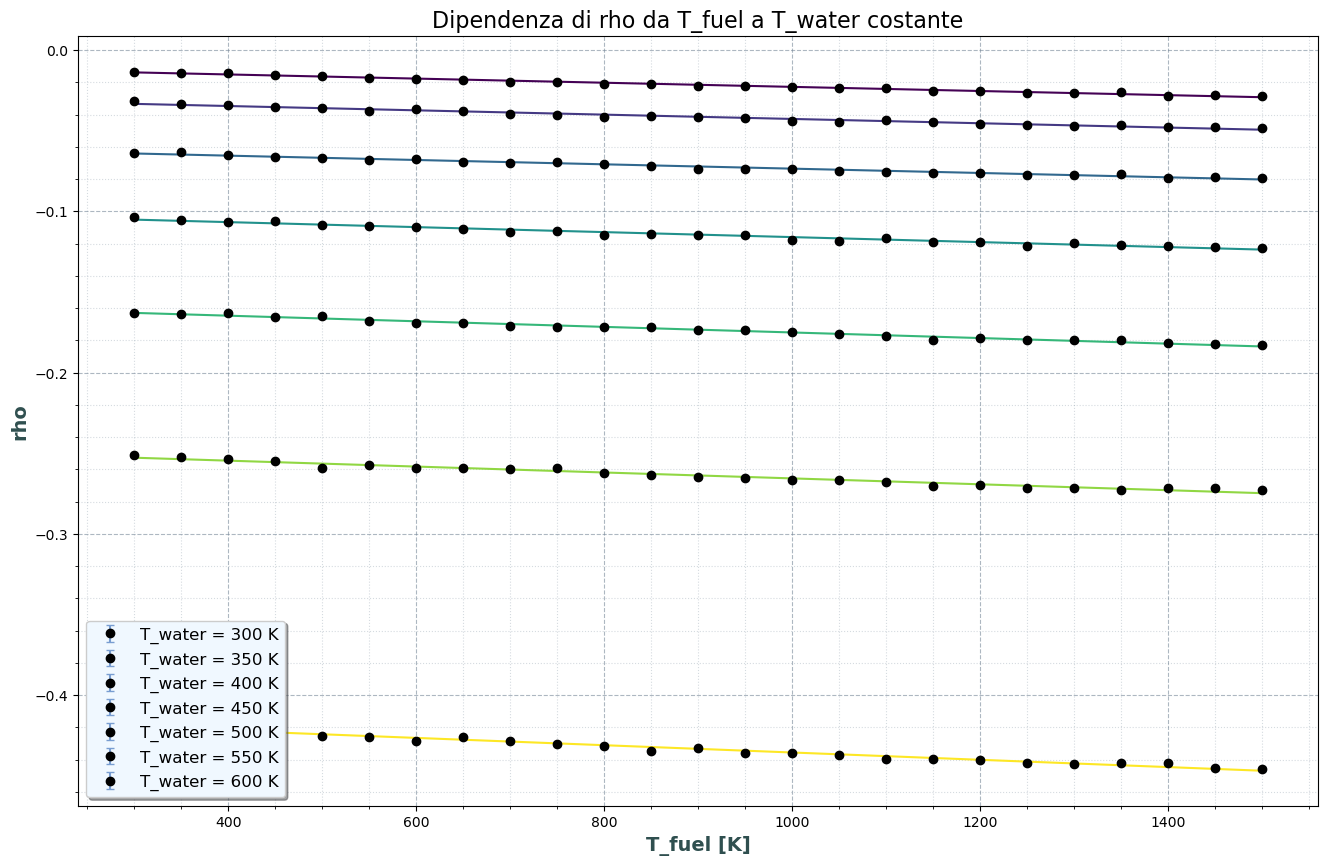

In [32]:
plt.figure(figsize=(16, 10))
t_waters = df['T_water'].unique()
colori_tw = plt.cm.viridis(np.linspace(0, 1, len(t_waters)))

m_values = []
err_m_values = []

for i, tw in enumerate(t_waters):
    df_sub = df[df['T_water'] == tw]
    x = df_sub['T_fuel']
    y = df_sub['k_eff']
    yerr = df_sub['std_dev']

    rho = (y-1)/y
    y = rho

    # Propagazione dell'errore per rho
    yerr = yerr / df_sub['k_eff']**2

    # Fit lineare pesato: y = m*x + q
    # Usiamo w = 1/yerr (np.polyfit richiede i pesi come 1/sigma)
    p, cov = np.polyfit(x, y, 1, w=1/yerr, cov=True)
    m, q = p
    err_m, err_q = np.sqrt(np.diag(cov))

    # Salvataggio dei coefficienti
    m_values.append(m)
    err_m_values.append(err_m)

    # Stampa dei parametri a schermo
    print(f"T_water = {tw:.0f} K | m = {m:.4e} +/- {err_m:.4e} | q = {q:.4e} +/- {err_q:.4e}")

    # Plot dei punti con barre d'errore
    plt.errorbar(x, y, yerr=yerr,
                 fmt='o', color=colori_tw[i],
                 markerfacecolor='#000000', markeredgecolor='#000000',
                 ecolor='#789DD1', capsize=3,
                 label=f'T_water = {int(tw)} K')

    # Plot della retta di fit
    plt.plot(x, np.polyval(p, x), '-', color=colori_tw[i])
    m_array = np.array(m_values)
    err_m_array = np.array(err_m_values)

plt.title('Dipendenza di rho da T_fuel a T_water costante', fontsize=16)
plt.xlabel('T_fuel [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('rho', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()



In [33]:
# 1. Calcolo dei pesi (inversamente proporzionali alla varianza)
pesi = 1.0 / (err_m_array**2)

# 2. Calcolo della media pesata e del suo errore
m_mean = np.sum(m_array * pesi) / np.sum(pesi)
err_m_mean = 1.0 / np.sqrt(np.sum(pesi))

print(f"--- RISULTATI MEDIA PESATA ---")
print(f"Media pesata (m): {m_mean:.4e} +/- {err_m_mean:.4e}\n")

# 3. Valutazione della compatibilità
print(f"--- COMPATIBILITÀ DEI SINGOLI VALORI ---")
for i, (m, err_m) in enumerate(zip(m_array, err_m_array)):
    # Propagazione dell'errore per la differenza (m - m_mean)
    sigma_diff = np.sqrt(err_m**2 + err_m_mean**2)
    
    # Distanza in deviazioni standard (Z-score)
    z_score = np.abs(m - m_mean) / sigma_diff
    
    # Criterio standard di 3 sigma per la compatibilità
    is_compatibile = "SI" if z_score <= 2.0 else "NO"
    
    print(f"Dataset {i+1}: m = {m:.4e} +/- {err_m:.4e} | "
          f"Scarto: {np.abs(m - m_mean):.4e} | "
          f"Distanza: {z_score:.2f} σ | Compatibile (< 2σ): {is_compatibile}")

--- RISULTATI MEDIA PESATA ---
Media pesata (m): -1.4780e-05 +/- 1.7308e-07

--- COMPATIBILITÀ DEI SINGOLI VALORI ---
Dataset 1: m = -1.2824e-05 +/- 2.9430e-07 | Scarto: 1.9551e-06 | Distanza: 5.73 σ | Compatibile (< 2σ): NO
Dataset 2: m = -1.3352e-05 +/- 4.6456e-07 | Scarto: 1.4275e-06 | Distanza: 2.88 σ | Compatibile (< 2σ): NO
Dataset 3: m = -1.3427e-05 +/- 4.2520e-07 | Scarto: 1.3527e-06 | Distanza: 2.95 σ | Compatibile (< 2σ): NO
Dataset 4: m = -1.5479e-05 +/- 5.6085e-07 | Scarto: 6.9976e-07 | Distanza: 1.19 σ | Compatibile (< 2σ): SI
Dataset 5: m = -1.7337e-05 +/- 4.8039e-07 | Scarto: 2.5576e-06 | Distanza: 5.01 σ | Compatibile (< 2σ): NO
Dataset 6: m = -1.8318e-05 +/- 6.8369e-07 | Scarto: 3.5383e-06 | Distanza: 5.02 σ | Compatibile (< 2σ): NO
Dataset 7: m = -2.2606e-05 +/- 7.0397e-07 | Scarto: 7.8263e-06 | Distanza: 10.80 σ | Compatibile (< 2σ): NO


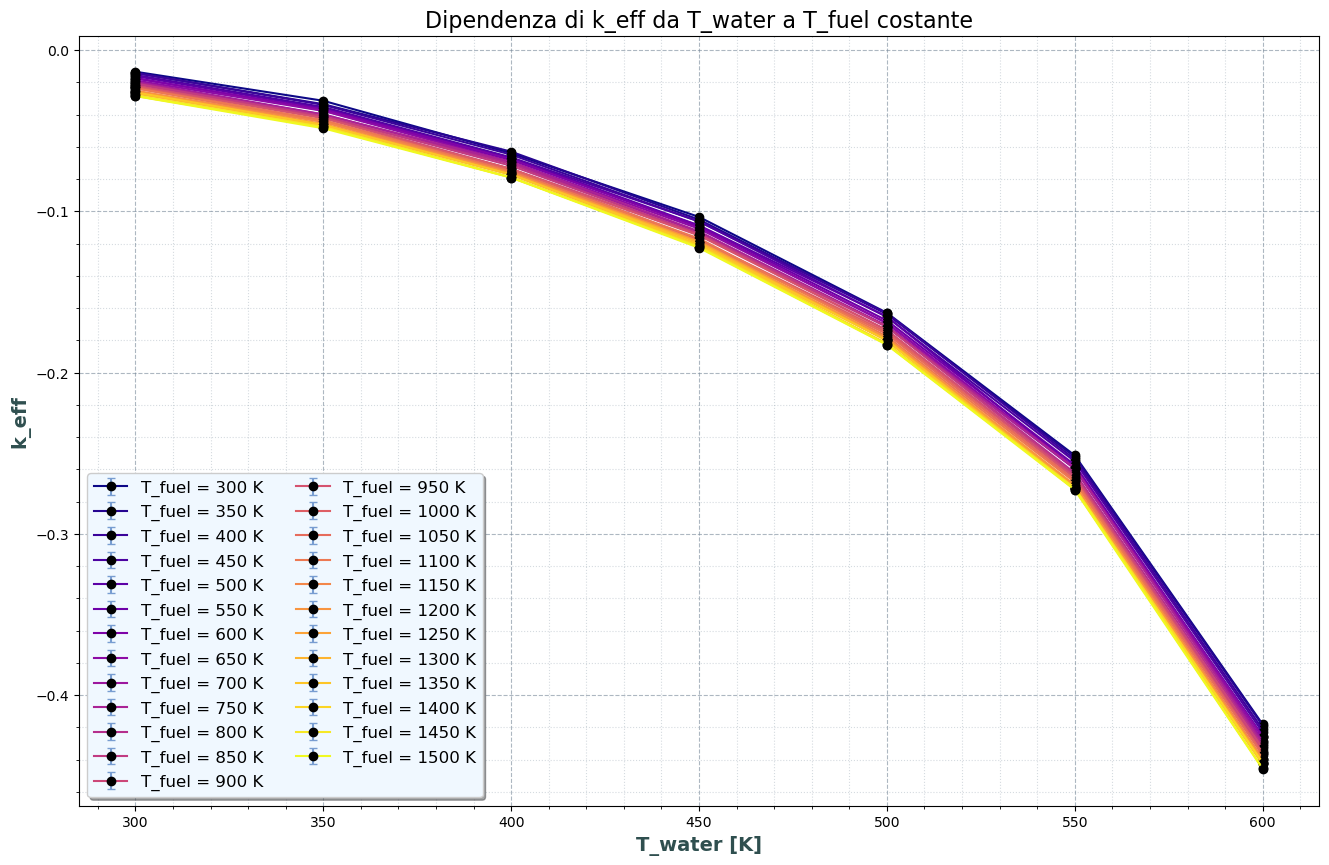

In [34]:
plt.figure(figsize=(16, 10))
t_fuels = df['T_fuel'].unique()
colori_tf = plt.cm.plasma(np.linspace(0, 1, len(t_fuels)))

for i, tf in enumerate(t_fuels):
    df_sub = df[df['T_fuel'] == tf]
    plt.errorbar(df_sub['T_water'], (df_sub['k_eff']-1)/df_sub['k_eff'], yerr=df_sub['std_dev']/df_sub['k_eff']**2,
                 fmt='o-', color=colori_tf[i],
                 markerfacecolor='#000000', markeredgecolor='#000000',
                 ecolor='#789DD1', capsize=3,
                 label=f'T_fuel = {int(tf)} K')

plt.title('Dipendenza di k_eff da T_water a T_fuel costante', fontsize=16)
plt.xlabel('T_water [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('k_eff', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.minorticks_on()
plt.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF', ncol=2)

plt.show()